# Part 3 — Feature Engineering, Selection and Ridge Tuning

### Imports

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
from sklearn.linear_model import *

### Loading Data

In [62]:
df_bike_counts = pd.read_csv('bike_project_data/bike_counts.csv', sep=',', names=["datetime","station","latitude","longitude","bike_count"], header=0)
df_holidays = pd.read_csv('bike_project_data/danish_holidays.csv', sep=',', names=["date","holiday"], header=0)
df_stations = pd.read_csv('bike_project_data/stations.csv', sep=',', names=["station","latitude","longitude","daily_avg_2021"], header=0)
df_weather = pd.read_csv('bike_project_data/weather_copenhagen.csv', sep=',', names=["datetime","temperature_C","wind_speed_ms","precipitation_mm"], header=0)

### Splitting Data - Langebro Station

In [63]:
Station = "Langebro"

df_bike_counts["datetime"] = pd.to_datetime(df_bike_counts["datetime"])
df_weather["datetime"] = pd.to_datetime(df_weather["datetime"])
df_holidays["datetime"] = pd.to_datetime(df_holidays["date"])
df_holidays["holiday"] = True

df_merged = pd.merge(df_bike_counts, df_weather, on="datetime", how="left")

df_merged["date"] = df_merged["datetime"].dt.date
df_holidays["date"] = df_holidays["datetime"].dt.date

df_merged = pd.merge(df_merged, df_holidays[["date", "holiday"]], on="date", how="left")
df_merged["holiday"] = df_merged["holiday"].fillna(False)

df_merged.ffill(inplace=True)

df_training   = df_merged[(df_merged["datetime"].dt.year == 2021) & (df_merged["station"] == Station)].copy()
df_validating = df_merged[(df_merged["datetime"].dt.year == 2022) & (df_merged["station"] == Station)].copy()
df_testing    = df_merged[(df_merged["datetime"].dt.year == 2023) & (df_merged["station"] == Station)].copy()

C:\Users\Bruger\AppData\Local\Temp\ipykernel_20176\2438475919.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_merged["holiday"] = df_merged["holiday"].fillna(False)


### Helper functions
Same style as part_2 — with two fixes:
- `ridge_reg` now uses `X.shape[1]` (number of features), not `X.shape[0]`.
- `calculate_RMSE` uses **mean**, so train / val / test errors are comparable.

In [64]:
def linear_reg(X, y):
    return np.linalg.solve(X.T @ X, X.T @ y)

def ridge_reg(X, y, lam):
    return np.linalg.solve(X.T @ X + lam * np.eye(X.shape[1]), X.T @ y)

def calculate_RMSE(X, w, y_true):
    y_pred = np.maximum((X @ w).flatten(), 0)
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

def standardize_train(X):
    # leave intercept (col 0) untouched
    mu = X[:, 1:].mean(axis=0)
    sigma = X[:, 1:].std(axis=0)
    sigma = np.where(sigma == 0, 1.0, sigma)
    X_std = X.copy().astype(float)
    X_std[:, 1:] = (X[:, 1:] - mu) / sigma
    return X_std, mu, sigma

def standardize_apply(X, mu, sigma):
    X_std = X.copy().astype(float)
    X_std[:, 1:] = (X[:, 1:] - mu) / sigma
    return X_std

### Feature engineering — generate all candidates
Extends `build_system` from part_2:
- hour harmonics k=1..6 (higher k = sharper peaks for commute)
- dayofyear cycle, first AND second harmonic (uses `dayofyear`, fixes the `dt.day / 365` bug)
- day-of-week cycle, weekend / holiday / workday indicators
- quadratic temp / wind, log(1+precip), is_raining
- hour × workday for **all** harmonics (commute spikes only on workdays)
- temp / precip / wind × workday (commuters react to weather differently than weekend cyclists)

In [65]:
def add_features(df):
    df = df.copy()
    h   = df["datetime"].dt.hour
    doy = df["datetime"].dt.dayofyear
    dow = df["datetime"].dt.dayofweek

    # cyclical hour at multiple harmonics — k up to 6 captures sharp commute spikes
    for k in [1, 2, 3, 4, 5, 6]:
        df[f"h_sin{k}"] = np.sin(2 * np.pi * k * h / 24)
        df[f"h_cos{k}"] = np.cos(2 * np.pi * k * h / 24)

    # seasonal cycle — first and second harmonic of dayofyear
    df["d_sin1"] = np.sin(2 * np.pi * doy / 365)
    df["d_cos1"] = np.cos(2 * np.pi * doy / 365)
    df["d_sin2"] = np.sin(4 * np.pi * doy / 365)
    df["d_cos2"] = np.cos(4 * np.pi * doy / 365)

    # day of week (cyclical)
    df["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    df["dow_cos"] = np.cos(2 * np.pi * dow / 7)

    # calendar indicators
    df["is_weekend"] = (dow >= 5).astype(float)
    df["is_holiday"] = df["holiday"].astype(float)
    df["is_workday"] = ((1 - df["is_weekend"]) * (1 - df["is_holiday"])).astype(float)

    # weather
    df["temp"]       = df["temperature_C"]
    df["temp_sq"]    = df["temperature_C"] ** 2
    df["wind"]       = df["wind_speed_ms"]
    df["wind_sq"]    = df["wind_speed_ms"] ** 2
    df["precip"]     = df["precipitation_mm"]
    df["log_precip"] = np.log1p(df["precipitation_mm"])
    df["is_raining"] = (df["precipitation_mm"] > 0.1).astype(float)

    # commute interactions: hour × workday for ALL harmonics
    for k in [1, 2, 3, 4, 5, 6]:
        df[f"h_sin{k}_wd"] = df[f"h_sin{k}"] * df["is_workday"]
        df[f"h_cos{k}_wd"] = df[f"h_cos{k}"] * df["is_workday"]

    # weather × workday interactions
    df["temp_wd"]   = df["temp"] * df["is_workday"]
    df["precip_wd"] = df["precip"] * df["is_workday"]
    df["wind_wd"]   = df["wind"] * df["is_workday"]

    return df


df_training   = add_features(df_training)
df_validating = add_features(df_validating)
df_testing    = add_features(df_testing)


def build_X(df, feature_names):
    n = df.shape[0]
    cols = [np.ones(n)]
    for name in feature_names:
        cols.append(df[name].values.astype(float))
    return np.column_stack(cols)


y_tr = df_training["bike_count"].values
y_va = df_validating["bike_count"].values
y_te = df_testing["bike_count"].values

### Baseline recap (matches part_2's improved model)

In [66]:
baseline_features = ["h_sin1", "h_cos1", "h_sin2", "h_cos2",
                     "is_weekend", "is_holiday", "temp"]

X_tr = build_X(df_training,   baseline_features)
X_va = build_X(df_validating, baseline_features)
X_tr_s, mu, sigma = standardize_train(X_tr)
X_va_s = standardize_apply(X_va, mu, sigma)

w_base = linear_reg(X_tr_s, y_tr)
print(f"Baseline val RMSE: {calculate_RMSE(X_va_s, w_base, y_va):.2f}")

Baseline val RMSE: 174.47


### Residual analysis (baseline)
Where residuals show structure, we need a feature. Big spikes at hour 8 / 17 motivate the workday × hour interactions and higher harmonics.

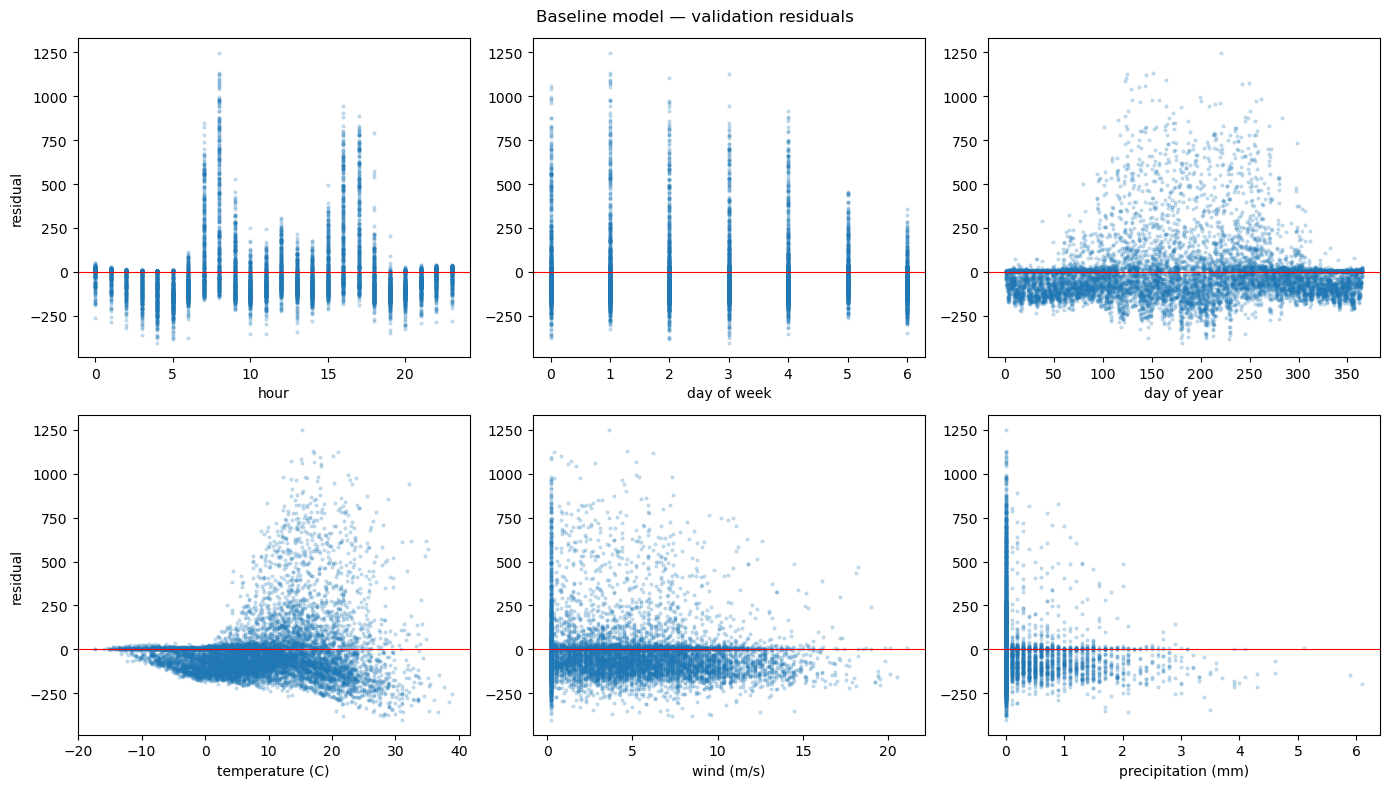

In [67]:
def plot_residuals(df_, residuals, title):
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes[0,0].scatter(df_["datetime"].dt.hour,        residuals, alpha=0.2, s=4)
    axes[0,0].set_xlabel("hour");           axes[0,0].set_ylabel("residual")
    axes[0,1].scatter(df_["datetime"].dt.dayofweek,   residuals, alpha=0.2, s=4)
    axes[0,1].set_xlabel("day of week")
    axes[0,2].scatter(df_["datetime"].dt.dayofyear,   residuals, alpha=0.2, s=4)
    axes[0,2].set_xlabel("day of year")
    axes[1,0].scatter(df_["temperature_C"],           residuals, alpha=0.2, s=4)
    axes[1,0].set_xlabel("temperature (C)"); axes[1,0].set_ylabel("residual")
    axes[1,1].scatter(df_["wind_speed_ms"],           residuals, alpha=0.2, s=4)
    axes[1,1].set_xlabel("wind (m/s)")
    axes[1,2].scatter(df_["precipitation_mm"],        residuals, alpha=0.2, s=4)
    axes[1,2].set_xlabel("precipitation (mm)")
    for ax in axes.flat:
        ax.axhline(0, color="red", linewidth=0.8)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


y_va_pred = np.maximum((X_va_s @ w_base).flatten(), 0)
plot_residuals(df_validating, y_va - y_va_pred, "Baseline model — validation residuals")

### Forward feature selection
Features are grouped so that paired sin/cos and interaction blocks go in/out together.

In [68]:
feature_groups = {
    "hour_24":       ["h_sin1", "h_cos1"],
    "hour_12":       ["h_sin2", "h_cos2"],
    "hour_8":        ["h_sin3", "h_cos3"],
    "hour_6":        ["h_sin4", "h_cos4"],
    "hour_4_8":      ["h_sin5", "h_cos5"],
    "hour_4":        ["h_sin6", "h_cos6"],
    "dayofyear_1":   ["d_sin1", "d_cos1"],
    "dayofyear_2":   ["d_sin2", "d_cos2"],
    "dayofweek":     ["dow_sin", "dow_cos"],
    "is_weekend":    ["is_weekend"],
    "is_holiday":    ["is_holiday"],
    "is_workday":    ["is_workday"],
    "temp":          ["temp"],
    "temp_sq":       ["temp_sq"],
    "wind":          ["wind"],
    "wind_sq":       ["wind_sq"],
    "precip":        ["precip"],
    "log_precip":    ["log_precip"],
    "is_raining":    ["is_raining"],
    "hour24_x_wd":   ["h_sin1_wd", "h_cos1_wd"],
    "hour12_x_wd":   ["h_sin2_wd", "h_cos2_wd"],
    "hour8_x_wd":    ["h_sin3_wd", "h_cos3_wd"],
    "hour6_x_wd":    ["h_sin4_wd", "h_cos4_wd"],
    "hour4_8_x_wd":  ["h_sin5_wd", "h_cos5_wd"],
    "hour4_x_wd":    ["h_sin6_wd", "h_cos6_wd"],
    "temp_x_wd":     ["temp_wd"],
    "precip_x_wd":   ["precip_wd"],
    "wind_x_wd":     ["wind_wd"],
}


def eval_features(feat_names, lam=0.0):
    X_tr = build_X(df_training,   feat_names)
    X_va = build_X(df_validating, feat_names)
    X_tr_s, mu, sigma = standardize_train(X_tr)
    X_va_s = standardize_apply(X_va, mu, sigma)
    w = ridge_reg(X_tr_s, y_tr, lam)
    return calculate_RMSE(X_va_s, w, y_va)


selected_groups, selected_features = [], []
remaining = list(feature_groups.keys())
best_rmse = eval_features([])
history = [("(intercept only)", best_rmse)]

while remaining:
    best_g, best_g_rmse = None, best_rmse
    for g in remaining:
        trial = selected_features + feature_groups[g]
        rmse = eval_features(trial)
        if rmse < best_g_rmse:
            best_g_rmse, best_g = rmse, g
    if best_g is None:
        break
    selected_groups.append(best_g)
    selected_features += feature_groups[best_g]
    remaining.remove(best_g)
    best_rmse = best_g_rmse
    history.append((best_g, best_rmse))

for g, r in history:
    print(f"{g:25s}  val RMSE = {r:.2f}")
print(f"\nSelected groups: {selected_groups}")

(intercept only)           val RMSE = 259.81
temp_x_wd                  val RMSE = 217.31
hour_24                    val RMSE = 191.17
hour_8                     val RMSE = 170.57
hour12_x_wd                val RMSE = 156.59
dayofyear_1                val RMSE = 146.37
hour_4_8                   val RMSE = 136.78
hour4_x_wd                 val RMSE = 133.15
hour24_x_wd                val RMSE = 130.46
hour_12                    val RMSE = 129.29
hour8_x_wd                 val RMSE = 127.92
wind                       val RMSE = 126.78
precip                     val RMSE = 126.10
hour4_8_x_wd               val RMSE = 125.62
hour_4                     val RMSE = 125.09
temp                       val RMSE = 124.77
hour6_x_wd                 val RMSE = 124.54
dayofyear_2                val RMSE = 124.50
hour_6                     val RMSE = 124.48
precip_x_wd                val RMSE = 124.46
log_precip                 val RMSE = 124.46
wind_sq                    val RMSE = 124.46

Selected 

### Ablation — start with everything, drop one group at a time

In [69]:
all_groups = list(feature_groups.keys())
all_feats  = [f for g in all_groups for f in feature_groups[g]]
full_rmse  = eval_features(all_feats)
print(f"Full model val RMSE: {full_rmse:.2f}\n")

for g in all_groups:
    reduced = [f for gg in all_groups if gg != g for f in feature_groups[gg]]
    rmse = eval_features(reduced)
    delta = rmse - full_rmse
    print(f"remove {g:25s}  val RMSE = {rmse:7.2f}  (delta = {delta:+.2f})")

Full model val RMSE: 127.18

remove hour_24                    val RMSE =  132.34  (delta = +5.16)
remove hour_12                    val RMSE =  129.11  (delta = +1.94)
remove hour_8                     val RMSE =  129.87  (delta = +2.69)
remove hour_6                     val RMSE =  127.19  (delta = +0.01)
remove hour_4_8                   val RMSE =  128.14  (delta = +0.96)
remove hour_4                     val RMSE =  127.66  (delta = +0.49)
remove dayofyear_1                val RMSE =  132.89  (delta = +5.72)
remove dayofyear_2                val RMSE =  127.24  (delta = +0.06)
remove dayofweek                  val RMSE =  126.99  (delta = -0.19)
remove is_weekend                 val RMSE =  127.22  (delta = +0.04)
remove is_holiday                 val RMSE =  127.22  (delta = +0.04)
remove is_workday                 val RMSE =  127.15  (delta = -0.03)
remove temp                       val RMSE =  127.42  (delta = +0.24)
remove temp_sq                    val RMSE =  124.48  (delta 

### Ridge regularization — pick λ on the validation set
Range now extends down to λ=10⁻⁵ and includes pure OLS (λ=0). With ~8700 training rows and ~50 features, the data is information-rich and we expect very little regularization is optimal — a flat curve at small λ is the correct answer, not a bug.

Best lambda: 0, val RMSE: 124.46
OLS (lam=0)  val RMSE: 124.46


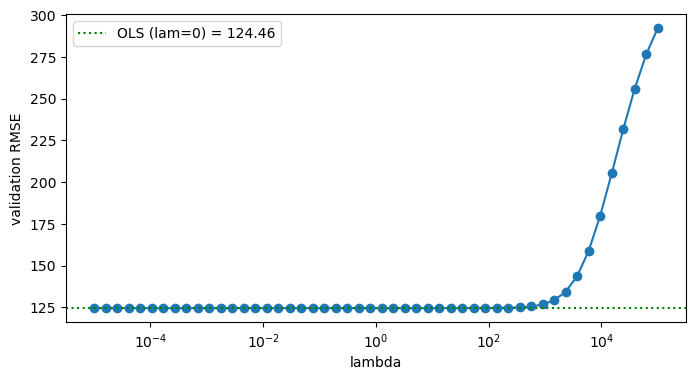

In [70]:
final_features = selected_features  # from forward selection

X_tr = build_X(df_training,   final_features)
X_va = build_X(df_validating, final_features)
X_te = build_X(df_testing,    final_features)
X_tr_s, mu, sigma = standardize_train(X_tr)
X_va_s = standardize_apply(X_va, mu, sigma)
X_te_s = standardize_apply(X_te, mu, sigma)

lambdas = np.concatenate([[0.0], np.logspace(-5, 5, 50)])
val_rmses = [calculate_RMSE(X_va_s, ridge_reg(X_tr_s, y_tr, lam), y_va) for lam in lambdas]

best_idx = int(np.argmin(val_rmses))
best_lam = lambdas[best_idx]
print(f"Best lambda: {best_lam:.6g}, val RMSE: {val_rmses[best_idx]:.2f}")
print(f"OLS (lam=0)  val RMSE: {val_rmses[0]:.2f}")

plt.figure(figsize=(8, 4))
# skip lam=0 in the plot since semilogx can't show it
plt.semilogx(lambdas[1:], val_rmses[1:], marker="o")
plt.axhline(val_rmses[0], color="green", linestyle=":", label=f"OLS (lam=0) = {val_rmses[0]:.2f}")
if best_lam > 0:
    plt.axvline(best_lam, color="red", linestyle="--", label=f"best lambda = {best_lam:.4g}")
plt.xlabel("lambda"); plt.ylabel("validation RMSE")
plt.legend(); plt.show()

### Final model — train, val, test

In [71]:
w_final = ridge_reg(X_tr_s, y_tr, best_lam)

print(f"train RMSE: {calculate_RMSE(X_tr_s, w_final, y_tr):.2f}")
print(f"val   RMSE: {calculate_RMSE(X_va_s, w_final, y_va):.2f}")
print(f"test  RMSE: {calculate_RMSE(X_te_s, w_final, y_te):.2f}")

train RMSE: 114.12
val   RMSE: 124.46
test  RMSE: 124.18


### Residuals after final model — verifies daily peaks are now captured
Compare to the baseline residual plot above. If the commute spikes at hour 8/17 are gone, the higher harmonics + workday interactions did their job.

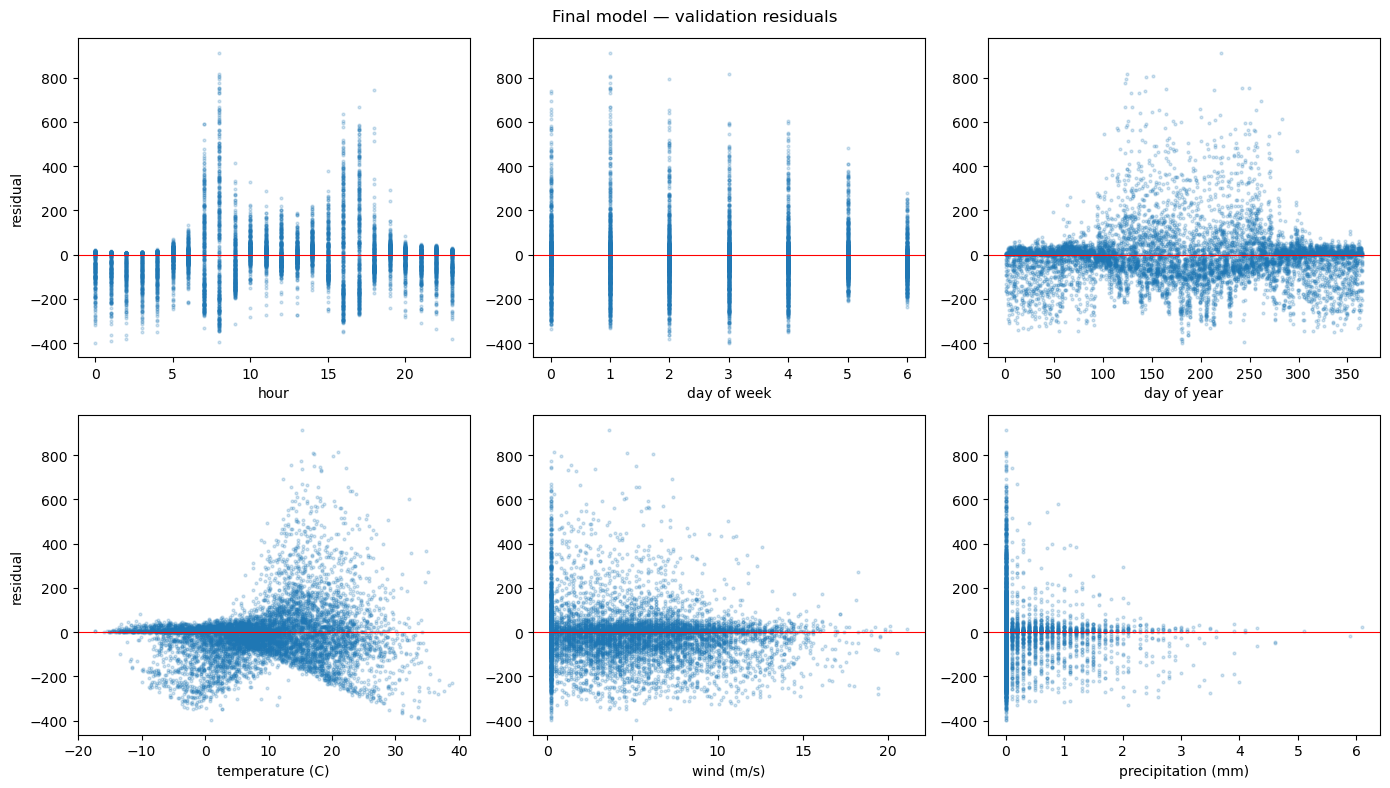

In [72]:
y_va_pred_final = np.maximum((X_va_s @ w_final).flatten(), 0)
plot_residuals(df_validating, y_va - y_va_pred_final, "Final model — validation residuals")

### Coefficient interpretation
Features are standardized, so coefficient magnitudes are directly comparable.

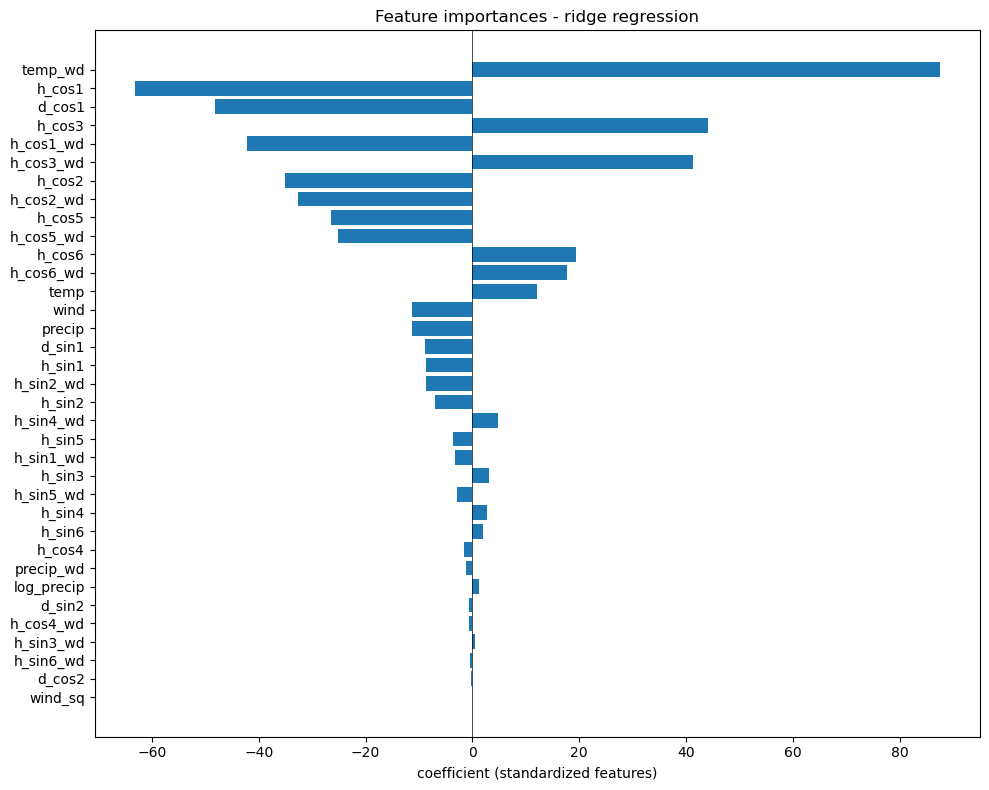

In [73]:
feat_labels = ["intercept"] + final_features
coefs = w_final.flatten()
order = np.argsort(np.abs(coefs[1:]))[::-1] + 1  # skip intercept

plt.figure(figsize=(10, 8))
plt.barh(np.array(feat_labels)[order][::-1], coefs[order][::-1])
plt.axvline(0, color="black", linewidth=0.5)
plt.xlabel("coefficient (standardized features)")
plt.title("Feature importances - ridge regression")
plt.tight_layout()
plt.show()

### Sanity check — predicted vs actual on a test week

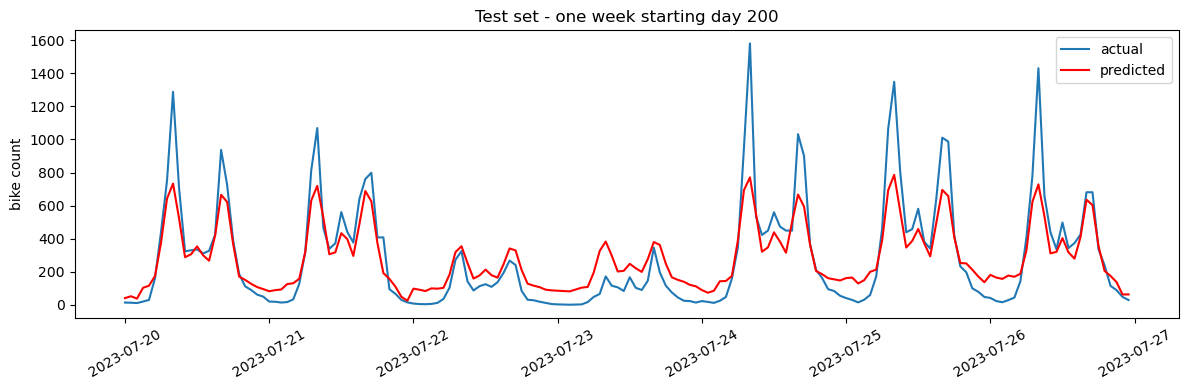

In [74]:
y_te_pred = np.maximum((X_te_s @ w_final).flatten(), 0)

day = 200
plt_hours = 24 * 7
plt.figure(figsize=(12, 4))
plt.plot(df_testing["datetime"].values[24*day : 24*day + plt_hours],
         y_te[24*day : 24*day + plt_hours], label="actual")
plt.plot(df_testing["datetime"].values[24*day : 24*day + plt_hours],
         y_te_pred[24*day : 24*day + plt_hours], color="red", label="predicted")
plt.legend(); plt.xticks(rotation=30); plt.ylabel("bike count")
plt.title(f"Test set - one week starting day {day}")
plt.tight_layout()
plt.show()

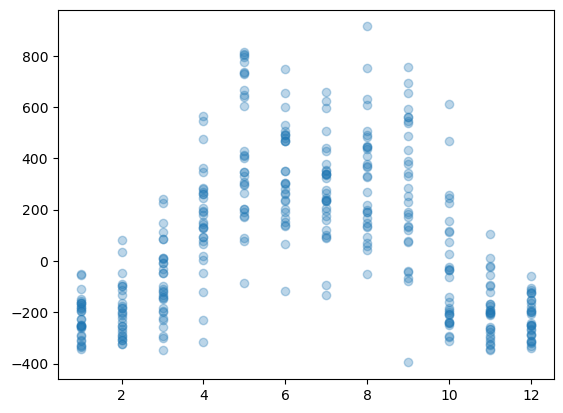

In [75]:
mask = df_validating["datetime"].dt.hour == 8
plt.scatter(df_validating.loc[mask, "datetime"].dt.month,
            (y_va - y_va_pred_final)[mask], alpha=0.3)